# Comprehensive Guide to Inferential Statistics in Python

This notebook explores the core inferential statistics used in data science. Inferential statistics allow us to make predictions or inferences about a population based on a sample of data.

**Covered in this Notebook:**
1. Setup and Understanding Our Mock Data
2. The Parametric vs. Non-Parametric Reference Guide
3. T-Tests (One-Sample, Independent, Paired)
4. Analysis of Variance (ANOVA)
5. Non-Parametric Tests (Mann-Whitney U, Chi-Square)
6. Correlation and Regression

---

## 1. Setup and Understanding Our Mock Data

Before running any statistical tests, we must understand our data. In the real world, you would perform Exploratory Data Analysis (EDA) first. Here, we are generating mock data using `numpy`. We use a random seed (`np.random.seed(42)`) to ensure that every time you run this notebook, the "random" numbers generated are exactly the same, making our results reproducible.

**Our Dataset Contains the Following Variables:**

* **`group_a` and `group_b` (Continuous):** Generated using a normal (Gaussian) distribution. These represent two independent groups (e.g., test scores from two different classrooms). We will use these for independent T-tests and ANOVA.
* **`before_treatment` and `after_treatment` (Continuous, Paired):** These represent measurements taken from the *same* subjects at two different times (e.g., blood pressure before and after medication). This dependence requires specific paired tests.
* **`category_1` and `category_2` (Categorical):** Randomly assigned text labels (e.g., color preferences and pass/fail status). We use these to test for associations between categories using tests like the Chi-Square.
* **`years_experience` (Continuous) and `salary` (Continuous, Correlated):** We generate years of experience uniformly, and then mathematically force `salary` to increase as experience increases. We do this specifically so our correlation and regression tests later on have a clear linear relationship to discover.

In [49]:
# Import necessary libraries
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Set random seed for reproducibility
np.random.seed(42)

# Generate Mock Data
data = pd.DataFrame({
    'group_a': np.random.normal(loc=50, scale=10, size=100),
    'group_b': np.random.normal(loc=55, scale=10, size=100),
    'group_c' : np.random.normal(loc=60, scale=10, size=100),
    'group_skewed': np.random.exponential(scale=10, size=100),
    'before_treatment': np.random.normal(loc=60, scale=8, size=100),
    'after_treatment': np.random.normal(loc=65, scale=8, size=100), # Paired with before
    'category_1': np.random.choice(['Red', 'Blue', 'Green'], size=100),
    'category_2': np.random.choice(['Pass', 'Fail'], size=100),
    'salary': np.random.normal(loc=60000, scale=15000, size=100),
    'years_experience': np.random.uniform(1, 20, size=100)
})

# Add a linear relationship for regression
data['salary'] = data['salary'] + (data['years_experience'] * 2500)

print("Data successfully generated. Ready for testing!")

Data successfully generated. Ready for testing!


In [50]:
display(data.head())
display(data.tail())

,group_a,group_b,group_c,group_skewed,before_treatment,after_treatment,category_1,category_2,salary,years_experience
0,54.967142,40.846293,63.577874,3.313339,77.518423,89.631046,Green,Fail,95331.940340,16.188902
1,48.617357,50.793547,65.607845,1.953333,53.533614,73.956599,Blue,Pass,89926.469376,14.199233
2,56.476885,51.572855,70.830512,13.887564,53.282225,63.976659,Blue,Pass,54314.218598,6.170758
3,65.230299,46.977227,70.538021,16.442092,55.204859,57.355676,Green,Pass,78868.706362,12.214383
4,47.658466,53.387143,46.223306,46.570049,43.008834,52.148429,Green,Pass,62987.622423,7.858504


,group_a,group_b,group_c,group_skewed,before_treatment,after_treatment,category_1,category_2,salary,years_experience
95,35.364851,58.853174,53.070904,11.899012,70.934994,63.247196,Red,Pass,111263.581319,9.880629
96,52.961203,46.161426,68.995999,6.061278,73.159742,71.635245,Green,Fail,82232.535121,12.654816
97,52.610553,56.537251,63.072995,9.876742,58.007712,47.310918,Blue,Fail,97620.840809,4.173645
98,50.051135,55.582087,68.128621,8.778259,64.612456,66.884916,Green,Fail,120196.788773,19.832204
99,47.654129,43.570297,66.296288,23.142328,62.490001,71.166922,Green,Pass,65067.404177,5.401762


## 1. T-Tests
T-tests are used to compare the means of groups.

* **One-Sample T-Test:** Tests if the mean of a single group is equal to a known value.
* **Independent Two-Sample T-Test:** Tests if the means of two independent groups are significantly different.
* **Paired T-Test:** Tests if the means of two related groups (e.g., same subjects before/after) are significantly different.

In [33]:
# --- 1A. One-Sample T-Test ---
# Hypothesis: Is the mean of 'group_a' significantly different from 48?
t_stat_1, p_val_1 = stats.ttest_1samp(data['group_a'], popmean=48)
print(f"One-Sample T-Test: t-statistic = {t_stat_1:.3f}, p-value = {p_val_1:.4f}")

# --- 1B. Independent Two-Sample T-Test ---
# Hypothesis: Are the means of 'group_a' and 'group_b' different?
t_stat_ind, p_val_ind = stats.ttest_ind(data['group_a'], data['group_b'], equal_var=False) # Welch's t-test
print(f"Independent T-Test: t-statistic = {t_stat_ind:.3f}, p-value = {p_val_ind:.4f}")

# --- 1C. Paired T-Test ---
# Hypothesis: Did the treatment have an effect? (comparing before vs after)
t_stat_pair, p_val_pair = stats.ttest_rel(data['before_treatment'], data['after_treatment'])
print(f"Paired T-Test: t-statistic = {t_stat_pair:.3f}, p-value = {p_val_pair:.4f}")

One-Sample T-Test: t-statistic = 1.059, p-value = 0.2923
Independent T-Test: t-statistic = -4.755, p-value = 0.0000
Paired T-Test: t-statistic = -3.761, p-value = 0.0003


## 2. Analysis of Variance (ANOVA)
ANOVA is used to compare the means of three or more independent groups.

* **One-Way ANOVA:** Tests if there are statistically significant differences between the means of three or more independent groups based on one factor.

In [34]:
# Create a 3rd group for ANOVA purposes
group_c = np.random.normal(loc=48, scale=10, size=100)

# Hypothesis: Are the means of group_a, group_b, and group_c equal?
f_stat, p_val_anova = stats.f_oneway(data['group_a'], data['group_b'], group_c)
print(f"One-Way ANOVA: F-statistic = {f_stat:.3f}, p-value = {p_val_anova:.4f}")

One-Way ANOVA: F-statistic = 12.971, p-value = 0.0000


## 3. Non-Parametric Tests
Used when the data does not meet the assumptions of parametric tests (e.g., not normally distributed, ordinal data, or categorical data).

* **Mann-Whitney U Test:** The non-parametric equivalent of the independent t-test.
* **Chi-Square Test of Independence:** Tests if there is a significant association between two categorical variables.

In [35]:
# --- 3A. Mann-Whitney U Test ---
# Hypothesis: Is the distribution of group_a equal to group_b?
u_stat, p_val_mw = stats.mannwhitneyu(data['group_a'], data['group_b'])
print(f"Mann-Whitney U: U-statistic = {u_stat:.3f}, p-value = {p_val_mw:.4f}")

# --- 3B. Chi-Square Test of Independence ---
# Create a contingency table first
contingency_table = pd.crosstab(data['category_1'], data['category_2'])

# Hypothesis: Are category_1 and category_2 independent?
chi2_stat, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Test: Chi2-statistic = {chi2_stat:.3f}, p-value = {p_val_chi:.4f}")

Mann-Whitney U: U-statistic = 3300.000, p-value = 0.0000
Chi-Square Test: Chi2-statistic = 5.332, p-value = 0.0695


## 4. Correlation and Regression
Used to evaluate relationships between numerical variables.

* **Pearson Correlation:** Measures linear relationship between two continuous variables.
* **Spearman Rank Correlation:** Non-parametric measure of rank correlation (monotonic relationships).
* **Ordinary Least Squares (OLS) Regression:** Models the linear relationship between a dependent variable and one or more independent variables.

In [36]:
# --- 4A. Correlation ---
# Pearson (Linear)
corr_p, p_val_p = stats.pearsonr(data['years_experience'], data['salary'])
print(f"Pearson Correlation: r = {corr_p:.3f}, p-value = {p_val_p:.4f}")

# Spearman (Non-linear/Rank based)
corr_s, p_val_s = stats.spearmanr(data['years_experience'], data['salary'])
print(f"Spearman Correlation: rho = {corr_s:.3f}, p-value = {p_val_s:.4f}")

# --- 4B. Simple Linear Regression (Statsmodels) ---
# Predict salary based on years of experience
# Add a constant for the intercept
X = sm.add_constant(data['years_experience']) 
y = data['salary']

model = sm.OLS(y, X).fit()
print("\n--- OLS Regression Summary ---")
print(model.summary())

Pearson Correlation: r = 0.677, p-value = 0.0000
Spearman Correlation: rho = 0.680, p-value = 0.0000

--- OLS Regression Summary ---
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     82.88
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           1.07e-14
Time:                        09:52:39   Log-Likelihood:                -1112.8
No. Observations:                 100   AIC:                             2230.
Df Residuals:                      98   BIC:                             2235.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025     

---

## 5. The Parametric vs. Non-Parametric Reference Guide

When choosing a statistical test, you must first decide between a parametric and a non-parametric method. 

**Parametric Methods** assume that your data follows a specific distribution (usually a normal distribution). They are more powerful but have strict assumptions (e.g., continuous data, equal variances, no extreme outliers).

**Non-Parametric Methods** are "distribution-free." They do not assume a normal distribution. You use these when your data is skewed, has heavy outliers, or consists of ordinal (ranked) data.

Here is a comprehensive mapping of common statistical goals to their appropriate tests:

| Statistical Goal | Parametric Method | Non-Parametric Equivalent |
| :--- | :--- | :--- |
| **Compare 1 group to a known value** | One-Sample T-Test | Wilcoxon Signed-Rank Test |
| **Compare 2 independent groups** | Independent Two-Sample T-Test | Mann-Whitney U Test |
| **Compare 2 related/paired groups** | Paired T-Test | Wilcoxon Signed-Rank Test |
| **Compare 3+ independent groups** | One-Way ANOVA | Kruskal-Wallis H Test |
| **Compare 3+ related groups** | Repeated Measures ANOVA | Friedman Test |
| **Measure relationship between 2 variables** | Pearson Correlation | Spearman Rank Correlation |
| **Predict a variable based on others** | Simple/Multiple Linear Regression | Non-parametric Regression / Decision Trees |
| **Test association of categorical variables** | N/A (Requires continuous data) | Chi-Square Test of Independence |

---
### Descriptive Statistics & Normality Checks

Before running statistical tests, we must check the **Normality Assumption**. Parametric tests (like T-Tests) assume the data follows a "Bell Curve" (Normal Distribution).

**Key Checks:**
1.  **Visual:** Histograms (is it bell-shaped?) and Q-Q Plots (do dots lie on the red line?).
2.  **Statistical:** Shapiro-Wilk Test.
    * **Null Hypothesis ($H_0$):** The data is normally distributed.
    * **p-value < 0.05:** Reject $H_0$ (Data is NOT normal $\rightarrow$ Use Non-Parametric).
    * **p-value > 0.05:** Fail to reject $H_0$ (Data IS normal $\rightarrow$ Use Parametric).

--- Checking Normality for: Group A (Normal) ---
Mean: 48.96, Median: 48.73
Skewness: -0.18 (0 is normal)
Kurtosis: -0.16 (0 is normal)
Shapiro-Wilk Test: p-value = 0.6552
Result: Likely Normal (Parametric OK)


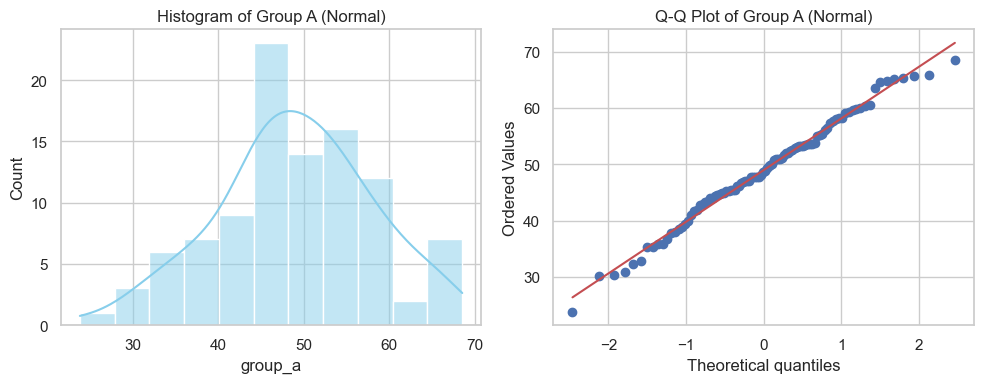

--- Checking Normality for: Group Skewed (Exponential) ---
Mean: 11.65, Median: 8.02
Skewness: 1.36 (0 is normal)
Kurtosis: 1.41 (0 is normal)
Shapiro-Wilk Test: p-value = 0.0000
Result: NOT Normal (Use Non-Parametric)


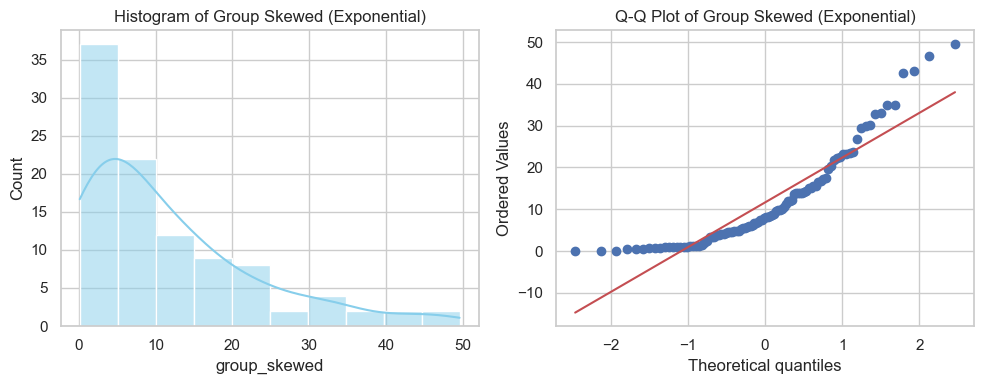

In [51]:
def check_normality(data_column, name):
    print(f"--- Checking Normality for: {name} ---")
    
    # 1. Descriptive Numbers
    print(f"Mean: {np.mean(data_column):.2f}, Median: {np.median(data_column):.2f}")
    print(f"Skewness: {stats.skew(data_column):.2f} (0 is normal)")
    print(f"Kurtosis: {stats.kurtosis(data_column):.2f} (0 is normal)")
    
    # 2. Shapiro-Wilk Test
    stat, p = stats.shapiro(data_column)
    print(f"Shapiro-Wilk Test: p-value = {p:.4f}")
    if p > 0.05:
        print("Result: Likely Normal (Parametric OK)")
    else:
        print("Result: NOT Normal (Use Non-Parametric)")
    
    # 3. Visualizations
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    # Histogram
    sns.histplot(data_column, kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'Histogram of {name}')
    
    # Q-Q Plot
    stats.probplot(data_column, dist="norm", plot=ax[1])
    ax[1].set_title(f'Q-Q Plot of {name}')
    
    plt.tight_layout()
    plt.show()

# Run check on a Normal Group
check_normality(data['group_a'], "Group A (Normal)")

# Run check on a Skewed Group
check_normality(data['group_skewed'], "Group Skewed (Exponential)")

---
Based on the descriptive checks above:
* If data is **Normal (Bell Curve)** $\rightarrow$ Use **Parametric**.
* If data is **Skewed/Not Normal** $\rightarrow$ Use **Non-Parametric**.


---
### 5A. Comparing One Group to a Known Value
**Goal:** Determine if a single sample's central tendency differs significantly from a known population value (e.g., testing if a factory's average part size equals 50mm).

In [37]:
known_value = 48

# Parametric: One-Sample T-Test (tests the mean)
t_stat_1, p_val_t1 = stats.ttest_1samp(data['group_a'], popmean=known_value)
print(f"One-Sample T-Test: t-statistic = {t_stat_1:.3f}, p-value = {p_val_t1:.4f}")

# Non-Parametric: Wilcoxon Signed-Rank Test (tests the median against a known value)
# We subtract the known value from the data to test if the median difference is 0
w_stat_1, p_val_w1 = stats.wilcoxon(data['group_a'] - known_value)
print(f"Wilcoxon 1-Sample Test: w-statistic = {w_stat_1:.3f}, p-value = {p_val_w1:.4f}")

One-Sample T-Test: t-statistic = 1.059, p-value = 0.2923
Wilcoxon 1-Sample Test: w-statistic = 2178.000, p-value = 0.2328


---
### 5B. Comparing Two Independent Groups
**Goal:** Determine if two entirely separate groups (e.g., Control Group vs. Test Group) have significantly different central tendencies.

In [38]:
# Parametric: Independent Two-Sample T-Test (Welch's t-test assuming unequal variances)
t_stat_ind, p_val_ind = stats.ttest_ind(data['group_a'], data['group_b'], equal_var=False)
print(f"Independent T-Test: t-statistic = {t_stat_ind:.3f}, p-value = {p_val_ind:.4f}")

# Non-Parametric: Mann-Whitney U Test
u_stat, p_val_mw = stats.mannwhitneyu(data['group_a'], data['group_b'])
print(f"Mann-Whitney U: U-statistic = {u_stat:.3f}, p-value = {p_val_mw:.4f}")

Independent T-Test: t-statistic = -4.755, p-value = 0.0000
Mann-Whitney U: U-statistic = 3300.000, p-value = 0.0000


---
### 5C. Comparing Two Related/Paired Groups
**Goal:** Determine if there is a significant difference when taking two measurements from the exact same subjects (e.g., Before and After a diet).

Paired T-Test: t-statistic = -3.761, p-value = 0.0003
Wilcoxon Paired Test: w-statistic = 1472.000, p-value = 0.0003


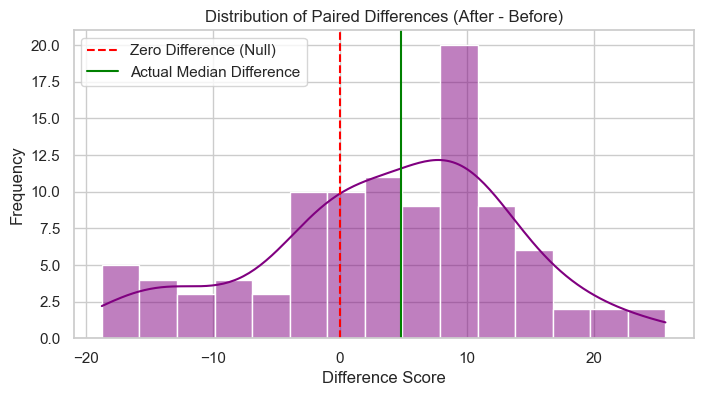

In [39]:
# Parametric: Paired T-Test
t_stat_pair, p_val_pair = stats.ttest_rel(data['before_treatment'], data['after_treatment'])
print(f"Paired T-Test: t-statistic = {t_stat_pair:.3f}, p-value = {p_val_pair:.4f}")

# Non-Parametric: Wilcoxon Signed-Rank Test (Paired)
stat_w, p_val_w = stats.wilcoxon(data['before_treatment'], data['after_treatment'])
print(f"Wilcoxon Paired Test: w-statistic = {stat_w:.3f}, p-value = {p_val_w:.4f}")

# --- Visualization: Boxplot of the Differences ---
differences = data['after_treatment'] - data['before_treatment']

plt.figure(figsize=(8, 4))
sns.histplot(differences, kde=True, color='purple', bins=15)
plt.axvline(x=0, color='red', linestyle='--', label='Zero Difference (Null)')
plt.axvline(x=np.median(differences), color='green', linestyle='-', label='Actual Median Difference')
plt.title('Distribution of Paired Differences (After - Before)')
plt.xlabel('Difference Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Interpretation:** If the p-value is less than 0.05, we reject the null hypothesis. The histogram visually supports this: if the green "Actual Median" line is far from the red "Zero Difference" line, the treatment likely had a significant effect.

---
### 5D. Comparing Three or More Independent Groups
**Goal:** Determine if at least one group among three or more independent groups is statistically different from the others.

One-Way ANOVA: F-statistic = 35.266, p-value = 0.0000
Kruskal-Wallis H Test: H-statistic = 57.175, p-value = 0.0000


C:\Users\ACER SWIFT 3\AppData\Local\Temp\ipykernel_5948\2928870959.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Score', data=melted_data, palette='Set2')


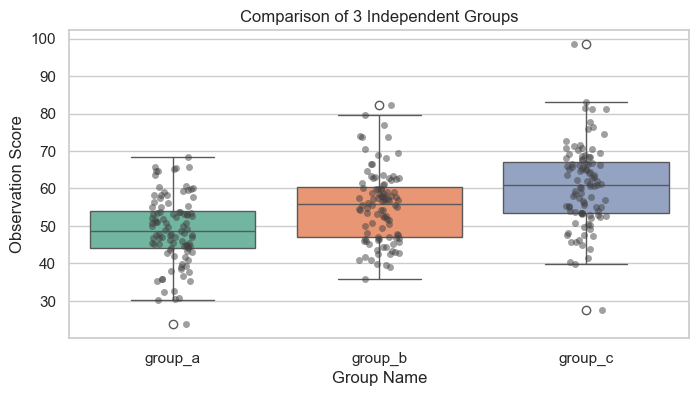

In [40]:
# Parametric: One-Way ANOVA
f_stat, p_val_anova = stats.f_oneway(data['group_a'], data['group_b'], data['group_c'])
print(f"One-Way ANOVA: F-statistic = {f_stat:.3f}, p-value = {p_val_anova:.4f}")

# Non-Parametric: Kruskal-Wallis H Test
stat_kw, p_val_kw = stats.kruskal(data['group_a'], data['group_b'], data['group_c'])
print(f"Kruskal-Wallis H Test: H-statistic = {stat_kw:.3f}, p-value = {p_val_kw:.4f}")

# --- Visualization: Boxplot Comparing the 3 Groups ---
# Restructure data for easier plotting with seaborn
melted_data = pd.melt(data[['group_a', 'group_b', 'group_c']], 
                      var_name='Group', value_name='Score')

plt.figure(figsize=(8, 4))
sns.boxplot(x='Group', y='Score', data=melted_data, palette='Set2')
sns.stripplot(x='Group', y='Score', data=melted_data, color=".25", alpha=0.5) 
plt.title('Comparison of 3 Independent Groups')
plt.xlabel('Group Name')
plt.ylabel('Observation Score')
plt.show()

**Interpretation:** A significant p-value (< 0.05) tells us *at least one* group is different, but it doesn't tell us *which* one. Visually, the boxplots help us spot the differences in medians (the horizontal lines inside the boxes) and overall spread.

---
### 5E. Correlation and Regression
**Goal:** Evaluate the relationship between numerical variables, and model how one variable predicts another.

Pearson Correlation: r = 0.677, p-value = 0.0000
Spearman Correlation: rho = 0.680, p-value = 0.0000

--- OLS Regression Summary ---
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.744e+04   3758.182     15.283      0.000       5e+04    6.49e+04
years_experience  2795.6250    307.090      9.104      0.000    2186.214    3405.036


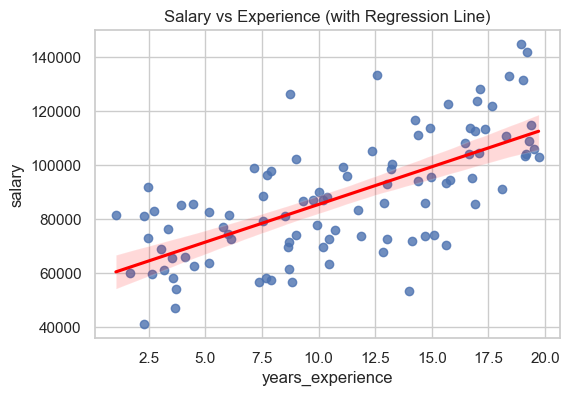

In [46]:
# Parametric Correlation: Pearson (Linear)
corr_p, p_val_p = stats.pearsonr(data['years_experience'], data['salary'])
print(f"Pearson Correlation: r = {corr_p:.3f}, p-value = {p_val_p:.4f}")

# Non-Parametric Correlation: Spearman (Rank-based, handles non-linear monotonic relationships)
corr_s, p_val_s = stats.spearmanr(data['years_experience'], data['salary'])
print(f"Spearman Correlation: rho = {corr_s:.3f}, p-value = {p_val_s:.4f}")

# Parametric Regression: Ordinary Least Squares (OLS)
# We add a constant (intercept) to our independent variable
X = sm.add_constant(data['years_experience']) 
y = data['salary']

model = sm.OLS(y, X).fit()
print("\n--- OLS Regression Summary ---")
print(model.summary().tables[1]) # Just printing the coefficients table for brevity

# Regression Plot
plt.figure(figsize=(6, 4))
sns.regplot(x='years_experience', y='salary', data=data, line_kws={"color": "red"})
plt.title('Salary vs Experience (with Regression Line)')
plt.show()

---
### 6F. Categorical Associations
**Goal:** Test if there is a significant association between two categorical variables (e.g., does passing/failing depend on color preference?).

Contingency Table:
 category_2  Fail  Pass
category_1            
Blue          21    17
Green         16    17
Red            8    21 

Chi-Square Test: Chi2-statistic = 5.332, p-value = 0.0695
Chi-Square Test: p-value = 0.0695


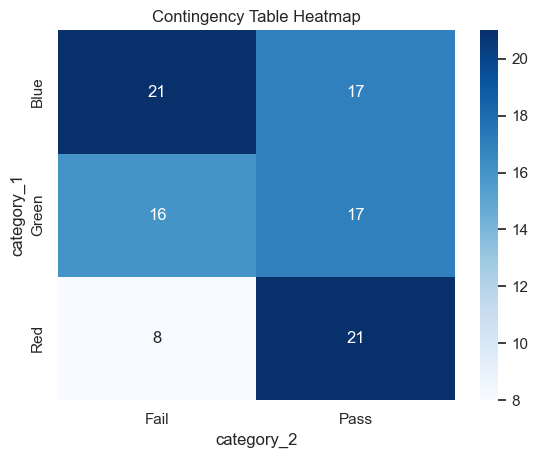

In [44]:
# Non-Parametric: Chi-Square Test of Independence
# First, create a contingency table (cross-tabulation)
contingency_table = pd.crosstab(data['category_1'], data['category_2'])
print("Contingency Table:\n", contingency_table, "\n")

# Run the Chi-Square test
chi2_stat, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Test: Chi2-statistic = {chi2_stat:.3f}, p-value = {p_val_chi:.4f}")

ct = pd.crosstab(data['category_1'], data['category_2'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"Chi-Square Test: p-value = {p:.4f}")
sns.heatmap(ct, annot=True, cmap="Blues", fmt='d')
plt.title("Contingency Table Heatmap")
plt.show()